<a href="https://colab.research.google.com/github/harshaesmayil/Face_Recognition/blob/main/mall_customer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Load the dataset (Make sure this path is correct for your Drive)
path = "/content/drive/MyDrive/Mall_Customers.csv"
df = pd.read_csv(path)

# 3. Select Features: Annual Income and Spending Score
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

print("✅ Step 1: Data Loaded Successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Step 1: Data Loaded Successfully


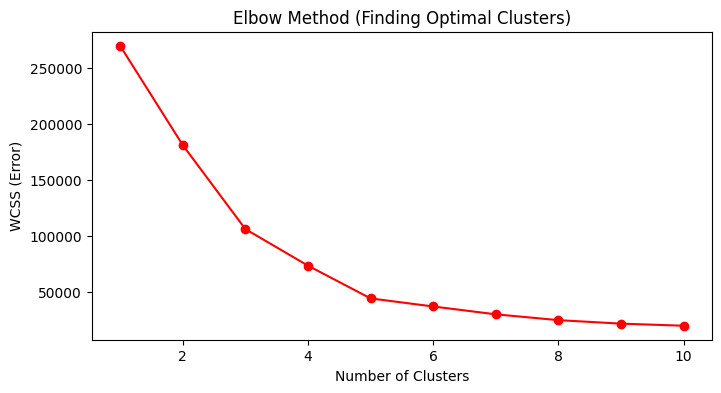

✅ Objective 1: K-Means completed with 5 optimal clusters.


In [ ]:
# 1. Elbow Method to find optimal clusters
wcss = []
for i in range(1, 11):
    kmeans_temp = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans_temp.fit(X)
    wcss.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', color='red')
plt.title('Elbow Method (Finding Optimal Clusters)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Error)')
plt.show()

# 2. Final K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df['KMeans_Clusters'] = kmeans.fit_predict(X)

print("✅ Objective 1: K-Means completed with 5 optimal clusters.")

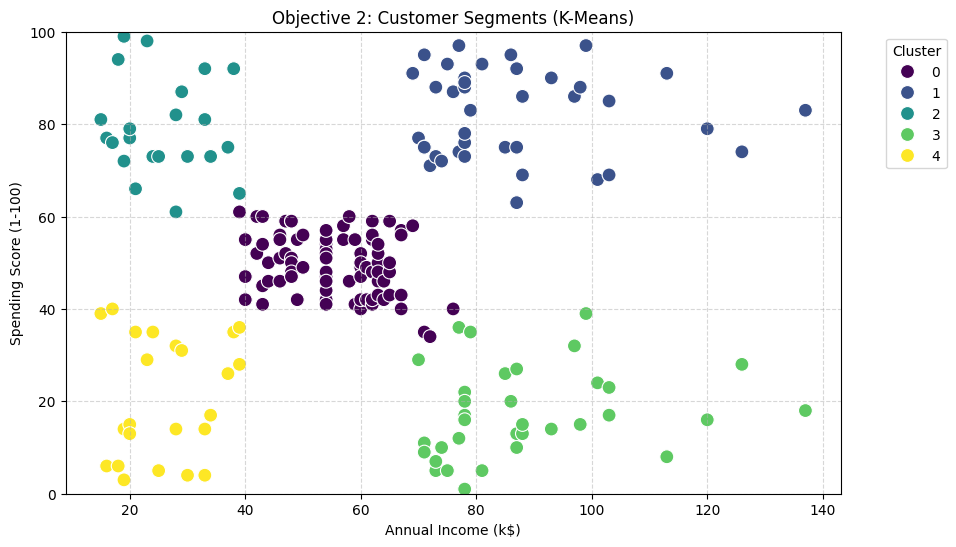

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the figure
plt.figure(figsize=(10, 6))

# 2. Create the scatter plot
sns.scatterplot(x=df['Annual Income (k$)'],
                y=df['Spending Score (1-100)'],
                hue=df['KMeans_Clusters'],
                palette='viridis', s=100)

# 3. FORCE THE AXIS DIRECTION (The Magic Fix)
# We set 0 as the bottom and 100 as the top explicitly
plt.ylim(0, 100)

# 4. Final Formatting
plt.title('Objective 2: Customer Segments (K-Means)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend out of the way
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
# 1. Prepare data for classification
# X = Features, y = The Clusters we found earlier
X_train, X_test, y_train, y_test = train_test_split(X, df['KMeans_Clusters'], test_size=0.3, random_state=42)

# 2. Train Random Forest Classifier (Ensemble Method)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("✅ Objective 3: Random Forest Ensemble Model trained.")

✅ Objective 3: Random Forest Ensemble Model trained.


Final Model Accuracy: 96.67%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        27
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00         6
           3       0.87      1.00      0.93        13
           4       1.00      1.00      1.00         5

    accuracy                           0.97        60
   macro avg       0.97      0.99      0.98        60
weighted avg       0.97      0.97      0.97        60



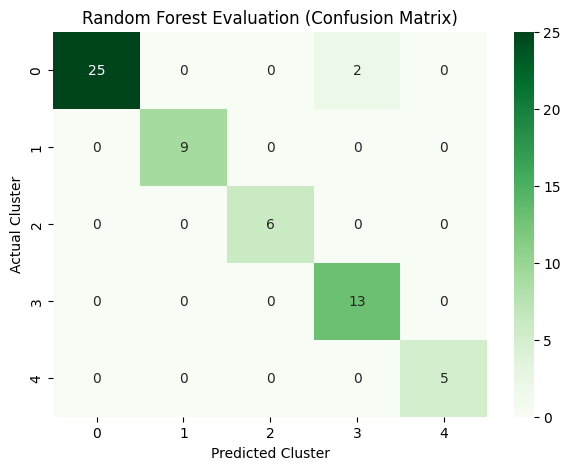

✅ Objective 4: Evaluation Metrics generated.


In [ ]:
# 1. Predict on test data
y_pred = rf_model.predict(X_test)

# 2. Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Final Model Accuracy: {accuracy * 100:.2f}%")

# 3. Detailed Performance Report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# 4. Confusion Matrix Visual
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Greens', fmt='d')
plt.title('Random Forest Evaluation (Confusion Matrix)')
plt.xlabel('Predicted Cluster')
plt.ylabel('Actual Cluster')
plt.show()

print("✅ Objective 4: Evaluation Metrics generated.")